## Name: Justus Kindt

## SciPro ID: 2026SS_07

# Homework_7: Soil Contamination by Factories

***

### Imports:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.cluster import k_means

***

## Introduction to the Assignment:

Soil contamination can arise from natural sources or human activity and can affect plants, animals, and human health.$^{[1,2]}$ In this assignment, the locations and contaminant concentrations of soil samples around three industrial buildings are analyzed. The sample coordinates are first grouped using K-means clustering. A radial exponential plume model supplied in the assignment is then fitted to the cluster associated with Building A to estimate the source position and contamination pattern.$^{[3]}$

### The Factory Layout:

The supplied assignment shows Building A north of the industrial-complex center, Building B to the south-east, and Building C to the south-west$^{[3]}$.  
The assignment image is not used here because the data-driven cluster plot in Task 2 provides the spatial evidence used in the analysis.

### The Data:

The supplied `soil_samples.csv` file contains three columns:
- the latitude (x),
- the longitude (y),
- the contaminant concentration (C(x,y)).

The coordinates are given in `meters` and the concentrations in `mg/kg`.

It is important to note that the latitude and longitude values are relative to the center of the industrial complex.$^{[3]}$.  

***

## Task 1: Data Preparation

The CSV file is loaded as a pandas DataFrame$^{[4]}$. Before the analysis, rows containing missing values or exact duplicates are removed. The number of removed rows is reported so that any modification of the supplied data remains transparent and reproducible.

In [2]:
input_data = pd.read_csv('soil_samples.csv', header=0, sep=',')
samples = input_data.dropna().drop_duplicates()
removed_rows = len(input_data) - len(samples)

print(f'Loaded {len(input_data)} rows.')
print(f'Removed {removed_rows} rows.')

samples.head(10)

Loaded 500 rows.
Removed 0 rows.


,Latitude (meters),Longitude (meters),Concentrations (mg/kg)
0,274.546475,-348.237786,1058.751507
1,225.487078,-659.404473,1121.188691
2,-155.177492,740.428479,306.002181
3,-1144.409587,-555.453236,26.718203
4,-206.499208,907.706669,393.790989
5,441.007705,-644.156001,1219.430205
6,266.752114,-148.522303,804.951156
7,154.904124,-429.994453,1016.263738
8,390.867731,668.775650,78.463438
9,-183.182198,566.828296,103.396012


***

## Task 2: Clustering and Visualization

This task groups the soil-sample locations into three spatial clusters using scikit-learn's K-means implementation$^{[5]}$.  
The resulting labels are added to the Task 1 DataFrame and visualized in a scatter plot.  

### Clustering the data:

K-means expects a two-dimensional input container with one row per sample and one column per feature. Here, each soil sample is represented by the coordinate pair $(x_i,y_i)$. The number of clusters is set to three because the assignment describes three buildings, therefore an elbow-method analysis is not required.

Setting the `random_state=0` allows the data to be easily reproducible.

In [3]:
coordinate_columns = ['Latitude (meters)', 'Longitude (meters)']
coordinates = samples[coordinate_columns]

if coordinates.shape[1] != 2:
    raise ValueError('K-means requires exactly two coordinate columns.')

if coordinates.isna().any().any():
    raise ValueError('The coordinates contain missing values.')


print(f'Number of samples: {len(coordinates)}')
print(f'Coordinate shape: {coordinates.shape}')
print(f'Missing coordinate values: {coordinates.isna().sum().sum()}')

coordinates.head(10)

Number of samples: 500
Coordinate shape: (500, 2)
Missing coordinate values: 0


,Latitude (meters),Longitude (meters)
0,274.546475,-348.237786
1,225.487078,-659.404473
2,-155.177492,740.428479
3,-1144.409587,-555.453236
4,-206.499208,907.706669
5,441.007705,-644.156001
6,266.752114,-148.522303
7,154.904124,-429.994453
8,390.867731,668.775650
9,-183.182198,566.828296


In [4]:
centroids, labels, inertia = k_means(X=coordinates, n_clusters=3,
                                     random_state=0, n_init='auto')

print(f'Centroids:\n {centroids}')
print(f'Labels:    {np.unique(labels)}')
print(f'Inertia:   {inertia:.2e}')

Centroids:
 [[-1000.50162719  -991.90883685]
 [   -2.85194769   990.54255048]
 [  405.97705449  -573.27880011]]
Labels:    [0 1 2]
Inertia:   5.50e+07


***

### Adding the labels to the DataFrame:

The cluster labels returned by K-means are added directly to the cleaned DataFrame from Task 1. With the specified random state, the assignment identifies label 1 as the cluster associated with Building A$^{[3]}$.  

In [5]:
samples['Cluster'] = labels

samples.head(10)

,Latitude (meters),Longitude (meters),Concentrations (mg/kg),Cluster
0,274.546475,-348.237786,1058.751507,2
1,225.487078,-659.404473,1121.188691,2
2,-155.177492,740.428479,306.002181,1
3,-1144.409587,-555.453236,26.718203,0
4,-206.499208,907.706669,393.790989,1
5,441.007705,-644.156001,1219.430205,2
6,266.752114,-148.522303,804.951156,2
7,154.904124,-429.994453,1016.263738,2
8,390.867731,668.775650,78.463438,1
9,-183.182198,566.828296,103.396012,1


In [6]:
counts = (samples['Cluster'].value_counts()
    .sort_index().rename('Number of samples'))

counts

Cluster
0    167
1    167
2    166
Name: Number of samples, dtype: int64

***

### Plotting the Clusters:

The sample locations, cluster labels, and centroids are visualized using Matplotlib.$^{[6]}$

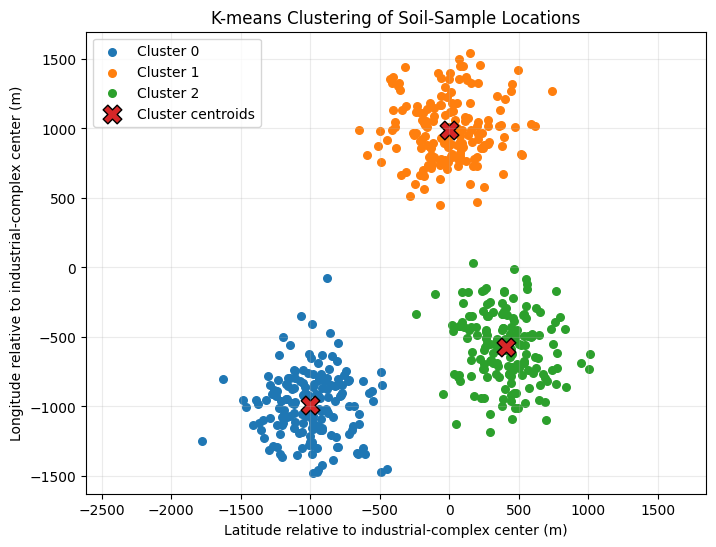

In [7]:
plt.figure(figsize=(8, 6))

for cluster_label in sorted(samples['Cluster'].unique()):
    cluster_data = samples[samples['Cluster'] == cluster_label]

    plt.scatter(x=cluster_data['Latitude (meters)'], 
                y=cluster_data['Longitude (meters)'],
                s=30, label=f'Cluster {cluster_label}')

plt.scatter(x=centroids[:, 0], y=centroids[:, 1],
            marker='X', s=180, edgecolors='black',
            label='Cluster centroids')

plt.xlabel('Latitude relative to industrial-complex center (m)')
plt.ylabel('Longitude relative to industrial-complex center (m)')
plt.title('K-means Clustering of Soil-Sample Locations')


plt.grid(alpha=0.25)
plt.axis('equal')
plt.legend()
plt.show()

The three clusters correspond to the regions (Buildings) shown in the assignment. Cluster 1 aligns with Building A, Cluster 2 lies to the south-east and aligns with Building B, while Cluster 0 lies to the south-west and aligns with Building C.

***

## Task 3: Model Parameter Optimization for Building A

A user-defined function encodes the plume equation below, which was supplied in the assignment$^{[3]}$.

The contamination-dispersion model is

$ 
C(x,y) = B + A\exp(- \frac{r}{L})
$

with 

$ 
r = \sqrt{(x - x_0)^2 + (y - y_0)^2}.
$

The variables and parameters are:

- $C(x,y)$: predicted contaminant concentration at location (x,y) in `milligrams of contaminant per kilogram of soil`,
- $A$: plume amplitude in `milligrams per kilogram`,
- $B$: background concentration in `milligrams per kilogram`,
- $L$: the decay length that controls how quickly the concentration decreases with distance  in `meters`,
- $r$: distance from the contamination source to the point (x,y) in `meters`,
- $x,y$: coordinates of a soil sample in `meters`,
- ($x_0,y_0$): coordinates of the contaminant source in `meters`.

SciPy's `curve_fit` function is then used to optimize the five parameters $A$, $B$, $x_0$, $y_0$, and $L$ for Cluster 1, which represents Building A$^{[7]}$.   

The Assignment provides initial starting guesses$^{[3]}$:
- $A = 1000$
- $B = 0$
- $x_0 = 0$
- $y_0 = 1000$
- $L = 500$


In [8]:
def plume_model(coordinates: tuple[np.ndarray, np.ndarray] | np.ndarray,
               amplitude: float, background: float, source_latitude: float,
               source_longitude: float, decay_length: float) -> np.ndarray:
    """Calculates contaminant concentrations using the plume model.

        Args:
        coordinates: Tuple containing arrays of latitude and longitude
            coordinates in meters.

        amplitude: Concentration amplitude A in mg/kg.

        background: Background concentration B in mg/kg.

        source_latitude: Estimated latitude coordinate x0 of the
            source in meters.

        source_longitude: Estimated longitude coordinate y0 of the
            source in meters.

        decay_length: Exponential decay length L in meters.

        Returns:
        np.ndarray: Predicted contaminant concentrations in mg/kg.

        Raises:
        ValueError: If the coordinates do not have shape (2, n)
            or the decay length equals zero.
    """
    try:
        coordinate_array = np.asarray(coordinates,
                                      dtype=float)
    except (TypeError, ValueError) as error:
        raise TypeError('Coordinates must contain numeric'
                        'latitude and longitude values.'
                       ) from error
        
        
    if (coordinate_array.ndim != 2 
        or coordinate_array.shape[0] != 2):
        raise ValueError('Coordinates must have shape '
                         '(2, number_of_samples).')

    if decay_length == 0:
        raise ValueError('The decay length must not equal zero.')
    
    latitude, longitude = coordinate_array

    # Calculate r
    distance_source = np.sqrt((latitude - source_latitude)**2 
                             + (longitude - source_longitude)**2)

    # Calculate C(x,y)
    predicted_concentration = (background + amplitude 
                               * np.exp(-distance_source / decay_length))

    return predicted_concentration

The optimization is restricted to Cluster 1 because the assignment identifies this cluster as Building A. A copy of the filtered DataFrame is created so that the predictions and residuals can later be added without modifying a view of the original DataFrame.

In [9]:
a_samples = samples.loc[samples['Cluster'] == 1].copy()

print(f'Number of samples assigned to Building A: {len(a_samples)}')
a_samples.head(10)

Number of samples assigned to Building A: 167


,Latitude (meters),Longitude (meters),Concentrations (mg/kg),Cluster
2,-155.177492,740.428479,306.002181,1
4,-206.499208,907.706669,393.790989,1
8,390.867731,668.775650,78.463438,1
9,-183.182198,566.828296,103.396012,1
17,-127.320275,861.803622,461.547412,1
18,87.983579,774.428851,394.394295,1
20,234.028736,964.706228,380.039213,1
25,-382.662638,856.149994,158.814545,1
27,13.373979,1262.605964,332.781797,1
31,-354.860699,1274.500970,113.383554,1


curve_fit requires independent data and dependent data. 
The latitude and longitude arrays are the independent data, while the measured concentration is dependent data.

The columns are converted to NumPy arrays because the model performs vectorized NumPy calculations.$^{[7,8]}$  

In [10]:
a_latitude = a_samples['Latitude (meters)'].to_numpy()
a_longitude = a_samples['Longitude (meters)'].to_numpy()
a_concentration = a_samples['Concentrations (mg/kg)'].to_numpy()

To test the user-defined function we will verify that it returns sensible outputs with the assignment's initial guesses.

In [11]:
initial_guesses = [
    1000.0,
    0.0,
    0.0,
    1000.0,
    500.0
]

initial_predictions = plume_model((a_latitude, a_longitude),
                                  *initial_guesses)


print(f'Some initial predictions values: {initial_predictions[:3]},')
print(f'and shape: {initial_predictions.shape}')

Some initial predictions values: [546.16257825 636.11784141 358.91488716],
and shape: (167,)


The parameters are now optimized by minimizing the residual differences between the measured concentrations and the plume-model values. The initial guesses are passed in the same order as the adjustable parameters in `plume_model`.

In [12]:
optimized_parameters, parameter_covariance = curve_fit(f=plume_model, xdata=(a_latitude,
                                                                             a_longitude),
                                                       ydata=a_concentration, p0=initial_guesses)

`curve_fit` returns two objects: `optimized_parameters` and `parameter_covariance`.  
The `optimized_parameters` contain the optimized parameters in the same order as the input `initial_guesses`, therefore we can extract them from that object.
Afterwards the square roots of the covariance-matrix diagonal are reported as estimated parameter standard errors$^{[7]}$.  

In [13]:
(optimized_amplitude, optimized_background,
optimized_source_latitude, optimized_source_longitude,
optimized_decay_length) = optimized_parameters 

parameter_standard_errors = np.sqrt(
    np.diag(parameter_covariance))

In [14]:
parameter_names = ['Amplitude A', 'Background B',
                   'Source latitude x0', 'Source longitude y0',
                   'Decay length L']

parameter_units = ['mg/kg', 'mg/kg', 'm', 'm', 'm']

optimized_parameter_table = pd.DataFrame({
    'Parameter': parameter_names, 'Optimized value': optimized_parameters,
    'Standard error': parameter_standard_errors, 'Unit': parameter_units})

optimized_parameter_table

,Parameter,Optimized value,Standard error,Unit
0,Amplitude A,1210.912911,64.784863,mg/kg
1,Background B,-484.950640,71.662323,mg/kg
2,Source latitude x0,-4.801459,2.429690,m
3,Source longitude y0,986.975875,2.347507,m
4,Decay length L,684.479060,64.098238,m


The initial predictions given in the assignment were not too far off of the optimized parameters with the exception of the background contamination which the initial prediction put at 0.0. A negative background contamination is physically not plausible as an actual contaminant concentration. This suggests that the simple exponential model uses the background parameter partly to compensate for deviations between the assumed radial plume shape and the observed data.

This is partly due to how `curve_fit` functions and the given instructions as they specified starting values but not parameter bounds.

***

## Task 4: Predict Building A's Contaminant Concentration and Visualize

The optimized parameters are substituted into the plume model to predict the concentration at every Building A sample location. The measured values are then plotted against the fitted values. An identity line represents perfect agreement between measurement and model prediction.

In [15]:
a_predictions = plume_model((a_latitude, a_longitude), *optimized_parameters)

print('First five measured concentrations:')
print(a_concentration[:5])

print('\nFirst five predicted concentrations:')
print(a_predictions[:5])

First five measured concentrations:
[306.00218089 393.79098875  78.46343816 103.39601164 461.54741151]

First five predicted concentrations:
[309.15816852 397.33522522  91.75465769 136.63705384 452.56723663]


Adding the predicted values to `a_samples` makes the comparison easier to inspect and to document. Furthermore with the predicted data it is possible to calculate the residual which can be used to determine how well the model predicted the contamination: a positive residual means the model underpredicts the measurements, a negative residual means the model overpredicts the measurement, and a residual near zero means the prediction is close to the measurement.

A residual is defined as 

$$
e_i = C_{i,\mathrm{measured}}-C_{i,\mathrm{predicted}}
$$

In [16]:
a_samples['Predicted Concentration (mg/kg)'] = a_predictions

a_samples['Residual (mg/kg)'] = (a_samples['Concentrations (mg/kg)']
                                 - a_samples['Predicted Concentration (mg/kg)'])

a_samples.head(10)

,Latitude (meters),Longitude (meters),Concentrations (mg/kg),Cluster,Predicted Concentration (mg/kg),Residual (mg/kg)
2,-155.177492,740.428479,306.002181,1,309.158169,-3.155988
4,-206.499208,907.706669,393.790989,1,397.335225,-3.544236
8,390.867731,668.775650,78.463438,1,91.754658,-13.291220
9,-183.182198,566.828296,103.396012,1,136.637054,-33.241042
17,-127.320275,861.803622,461.547412,1,452.567237,8.980175
18,87.983579,774.428851,394.394295,1,377.957119,16.437176
20,234.028736,964.706228,380.039213,1,367.993168,12.046045
25,-382.662638,856.149994,158.814545,1,190.200466,-31.385921
27,13.373979,1262.605964,332.781797,1,323.863659,8.918138
31,-354.860699,1274.500970,113.383554,1,139.771868,-26.388314


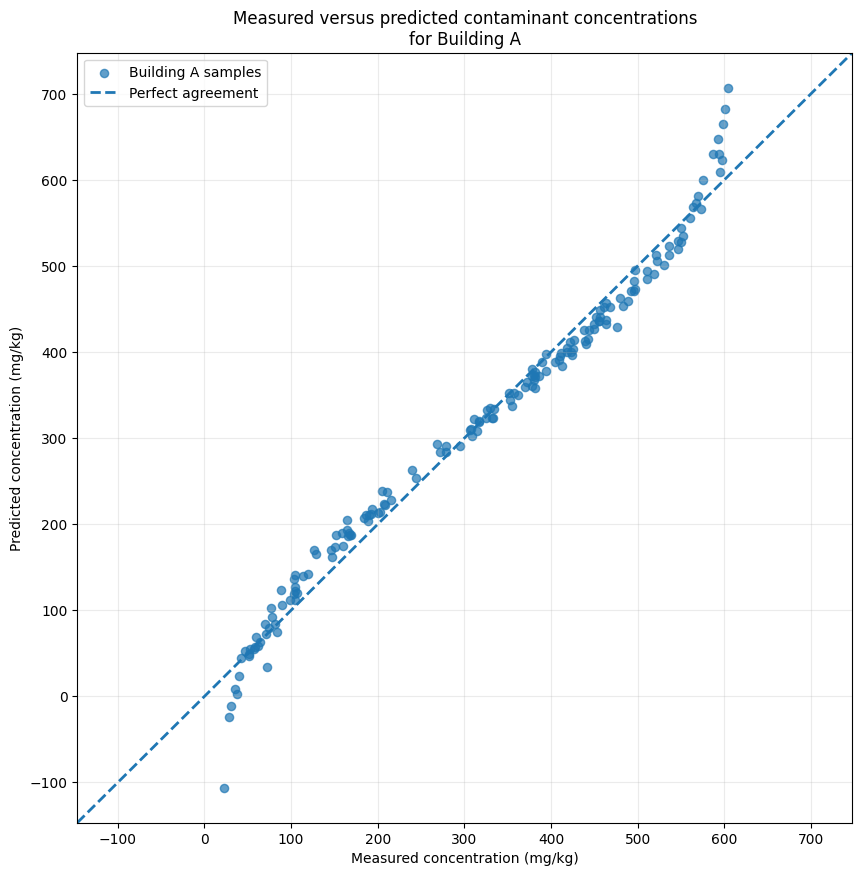

In [17]:
plot_min = min(a_concentration.min(), 
               a_predictions.min())
plot_max = max(a_concentration.max(), 
               a_predictions.max())

plot_range = plot_max - plot_min
plot_pad = 0.05 * plot_range

axis_lim = [plot_min - plot_pad, 
               plot_max + plot_pad]

plt.figure(figsize=(10, 10))

plt.scatter(a_concentration, a_predictions, s=35,
            alpha=0.7, label='Building A samples')

plt.plot(axis_lim, axis_lim,
         linestyle='--', linewidth=2, 
         label='Perfect agreement')

plt.xlabel('Measured concentration (mg/kg)')
plt.ylabel('Predicted concentration (mg/kg)')
plt.title('Measured versus predicted contaminant concentrations\n'
          'for Building A')

plt.xlim(axis_lim)
plt.ylim(axis_lim)

plt.grid(alpha=0.25)
plt.legend()
plt.show()

The above plot shows how close the predicted values are to the measured concentration.
Points close to the identity line represent points where the model prediction is close to the measured concentration. Points above the identity line mean the predicted value is greater than the measured value. Points below the identity line mean the predicted value is less than the measured value.

Most points lie near the identity line, indicating that the fitted plume reproduces the general concentration pattern in Cluster 1.

The systematic curvature and the negative predicted values at some low-concentration locations show that the simple radial exponential model does not represent every part of the data equally well.

***

## Task 5: Short Interpretation and Summary

The K-means algorithm separated the 500 sample locations into three clear spatial clusters. Following the assignment's label mapping, Cluster 1 represents Building A.  
The optimized plume model estimates the contamination source at approximately $(-4.80, 986.98)$ m, which is close to the expected Building A position at $(0, 1000)$ m.

The measured-versus-predicted scatter plot shows that most points are close to the identity line, so the model reproduces the overall concentration pattern around Building A. However, the systematic deviations from the line and several negative predicted concentrations show that the simple unconstrained radial plume model does not describe all samples perfectly. In particular, the negative optimized background concentration is not physically plausible and should be treated as a limitation of the model.

Overall, the notebook successfully clusters the sample locations, estimates the source of contamination for Building A, and visualizes how the plume-model predictions compare with the measured concentrations.

***

## References

[1] H. Zhang, B. Zhao, Y. Song, Y. Yang, L. Cai, Q. Miao, and T. Jiang. (2025). “Soil contamination in contaminated sites with key standards: A global analysis and perspective.” *Journal of Hazardous Materials*, 494, 138724. doi:10.1016/j.jhazmat.2025.138724.

[2] F. J. Zhao. (2018). “Soil and human health.” *European Journal of Soil Science*, 69, 158. doi:10.1111/ejss.12528.

[3] K. N. Kirschner. (2026). *Assignment: Soil Contamination by Factories*. Scientific Programming with Python, Hochschule Bonn-Rhein-Sieg, July 13, 2026.

[4] W. McKinney. (2010). “Data Structures for Statistical Computing in Python.” *Proceedings of the 9th Python in Science Conference*, 56–61.

[5] F. Pedregosa, G. Varoquaux, A. Gramfort, et al. (2011). “Scikit-learn: Machine Learning in Python.” *Journal of Machine Learning Research*, 12, 2825–2830.

[6] J. D. Hunter. (2007). “Matplotlib: A 2D Graphics Environment.” *Computing in Science & Engineering*, 9(3), 90–95. doi:10.1109/MCSE.2007.55.

[7] P. Virtanen, R. Gommers, T. E. Oliphant, et al. (2020). “SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python.” *Nature Methods*, 17, 261–272. doi:10.1038/s41592-019-0686-2.

[8] C. R. Harris, K. J. Millman, S. J. van der Walt, et al. (2020). “Array programming with NumPy.” *Nature*, 585, 357–362. doi:10.1038/s41586-020-2649-2.